# Classification and Evaluation in NLP

**Text classification** is a common Natural Language Processing (NLP) task where a model assigns a predefined category or label to a piece of text.

Examples include:
- Spam detection
- Sentiment analysis
- News categorization

In this lab, we will learn how to build and evaluate a text classification model.

## Case Study: Sentiment Analysis

Sentiment analysis, also known as opinion mining, its goal is to understand the information present in the text and categorize it as positive, negative, or neutral.

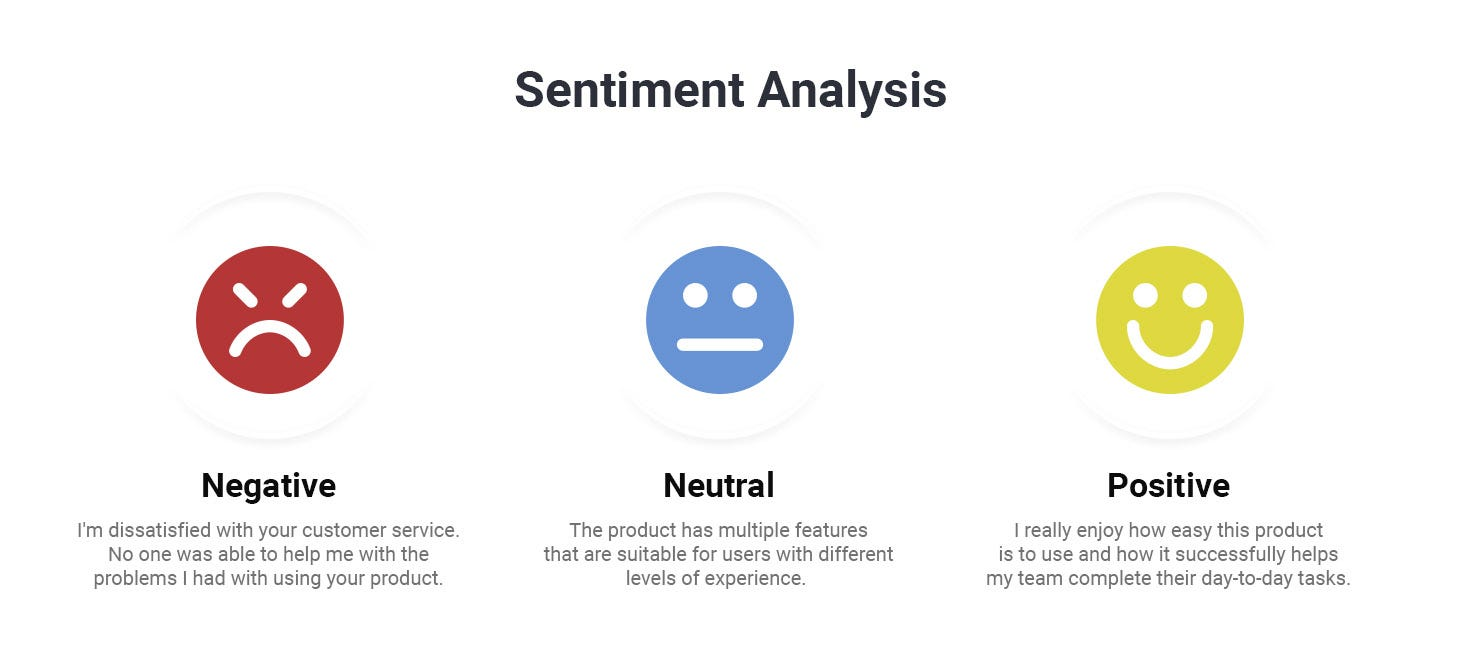

# Disneyland Reviews Dataset
In this lab we'll look into Disneyland Reviews dataset.  
*Link: https://www.kaggle.com/datasets/arushchillar/disneyland-reviews*

The dataset includes 42,000 reviews of 3 Disneyland branches - Paris, California and Hong Kong, posted by visitors on Trip Advisor.

Column Description:

- Review_ID: unique id given to each review
- Rating: ranging from 1 (unsatisfied) to 5 (satisfied)
- Year_Month: when the reviewer visited the theme park
- Reviewer_Location: country of origin of visitor
- Review_Text: comments made by visitor
- Disneyland_Branch: location of Disneyland Park

In [1]:
# Load the dataset
import pandas as pd

data = pd.read_csv('/content/DisneylandReviews.csv', encoding='latin-1')
data

FileNotFoundError: [Errno 2] No such file or directory: '/content/DisneylandReviews.csv'

In [ ]:
#Check for missing values
data.isna().sum()

,0
Review_ID,0
Rating,0
Year_Month,0
Reviewer_Location,0
Review_Text,0
Branch,0


In [ ]:
# Drop rows with missing values in the relevant columns
data = data.dropna(subset=['Review_Text', 'Rating'])

In [ ]:
# Map star ratings to sentiments
data['Sentiment'] = data['Rating'].apply(lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral'))
data.head()

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,Sentiment
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,positive
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,positive
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,positive
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,positive
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,positive


In [ ]:
# Import necessary libraries
import re
import nltk

def preprocess_text(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenize the text
    words = text.split()

    return ' '.join(words)

# Apply preprocessing to the review text
data['Review_Text'] = data['Review_Text'].apply(preprocess_text)

# Display cleaned reviews
data[['Review_Text', 'Sentiment']].head()

,Review_Text,Sentiment
0,if youve ever been to disneyland anywhere youl...,positive
1,its been a while since d last time we visit hk...,positive
2,thanks god it wasn t too hot or too humid when...,positive
3,hk disneyland is a great compact park unfortun...,positive
4,the location is not in the city took around ho...,positive


In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split the dataset into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(data['Review_Text'], data['Sentiment'], test_size=0.2, random_state=42)


# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # You can adjust max_features based on your dataset size - limit vocabulary to the 1000 most informative tokens
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

In [ ]:
print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

train_data size: (34124,)
test_data size: (8532,)


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train the Support Vector Machine (SVM) classifier
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(train_vectors, train_labels)

# Predictions on the test set
predictions = svm_classifier.predict(test_vectors)

# Evaluate the model
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:")
print(classification_report(test_labels, predictions))


Accuracy: 0.84
Classification Report:
              precision    recall  f1-score   support

    negative       0.64      0.54      0.58       720
     neutral       0.48      0.18      0.26      1035
    positive       0.88      0.98      0.92      6777

    accuracy                           0.84      8532
   macro avg       0.66      0.56      0.59      8532
weighted avg       0.81      0.84      0.81      8532



# Use Case:  Amazon reviews of unlocked phone analysis

The objective of this use case is to conduct sentiment analysis on Amazon reviews of unlocked phones, categorizing reviews into three classes: positive, negative, and neutral. The goal is to gain a comprehensive understanding of customer opinions and sentiments regarding various unlocked phone models.

- Dataset link: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

Task1: Load the data and do 5 different preprocessing steps on it

Task2: Use a proper train and test split

Task3: Do Feature Extraction Using TF-IDF

Task4: Train a Naive Bayes Classifier

Task5: Evaluate the model on the Test Set

Task6: Print the Confusion Matrix

In [ ]:

# Task 1: Load the data and do 5 different preprocessing steps on it

import os
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords

# 1. Load the dataset (handles current directory, lab4, or data folder)
data_path = 'Amazon_Unlocked_Mobile.csv' if os.path.exists('Amazon_Unlocked_Mobile.csv') else ('lab4/Amazon_Unlocked_Mobile.csv' if os.path.exists('lab4/Amazon_Unlocked_Mobile.csv') else 'data/Amazon_Unlocked_Mobile.csv')
data = pd.read_csv(data_path)

# Drop missing values in the relevant columns
data = data.dropna(subset=['Reviews', 'Rating'])

# Map star ratings to 3 sentiment classes: positive (> 3), negative (< 3), neutral (= 3)
data['Sentiment'] = data['Rating'].apply(lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral'))

# Download stopwords if needed
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

# Define preprocessing function with 5 distinct steps:
# Step 1: Convert text to lowercase
# Step 2: Remove URLs and HTML tags
# Step 3: Remove punctuation, numbers, and non-alphabetic characters
# Step 4: Tokenize text into words
# Step 5: Remove stopwords
def preprocess_text(text):
    # 1. Lowercasing
    text = str(text).lower()
    
    # 2. Removing URLs and HTML tags
    text = re.sub(r'http\S+|www\S+|<.*?>', '', text)
    
    # 3. Removing punctuation, numbers, and special characters
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # 4. Tokenization
    tokens = text.split()
    
    # 5. Stop words removal
    tokens = [w for w in tokens if w not in stop_words]
    
    return ' '.join(tokens)

# Apply preprocessing to the reviews
data['Cleaned_Reviews'] = data['Reviews'].apply(preprocess_text)

# Display sample of cleaned data
data[['Rating', 'Sentiment', 'Reviews', 'Cleaned_Reviews']].head()


,Rating,Sentiment,Reviews,Cleaned_Reviews
0,5,positive,"I feel so LUCKY to have found this used (phone to us & not used hard at all), phone on line from someone who upgraded and sold this one. My Son liked his old one that finally fell apart after 2.5+ years and didn't want an upgrade!! Thank you Seller, we really appreciate it & your honesty re: said used phone.I recommend this seller very highly & would but from them again!!",feel lucky found used phone us used hard phone line someone upgraded sold one son liked old one finally fell apart years want upgrade thank seller really appreciate honesty said used phone recommend seller highly would
1,4,positive,"nice phone, nice up grade from my pantach revue. Very clean set up and easy set up. never had an android phone but they are fantastic to say the least. perfect size for surfing and social media. great phone samsung",nice phone nice grade pantach revue clean set easy set never android phone fantastic say least perfect size surfing social media great phone samsung
2,5,positive,Very pleased,pleased
3,4,positive,It works good but it goes slow sometimes but its a very good phone I love it,works good goes slow sometimes good phone love
4,4,positive,"Great phone to replace my lost phone. The only thing is the volume up button does not work, but I can still go into settings to adjust. Other than that, it does the job until I am eligible to upgrade my phone again.Thaanks!",great phone replace lost phone thing volume button work still go settings adjust job eligible upgrade phone thaanks


In [ ]:
# Task 2: Use a proper train and test split

from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%) sets with stratified sampling
train_data, test_data, train_labels, test_labels = train_test_split(
    data['Cleaned_Reviews'],
    data['Sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=data['Sentiment']
)

print(f"Training set size: {train_data.shape[0]} reviews")
print(f"Testing set size:  {test_data.shape[0]} reviews")
print("\nClass distribution in Training Set:")
print(train_labels.value_counts())
print("\nClass distribution in Test Set:")
print(test_labels.value_counts())


Training set size: 331016 reviews
Testing set size:  82754 reviews

Class distribution in Training Set:
Sentiment
positive    227958
negative     77647
neutral      25411

Class distribution in Test Set:
Sentiment
positive    56990
negative    19412
neutral      6352


In [ ]:
# Task 3: Do Feature Extraction Using TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer (limiting vocabulary to 5,000 most informative features)
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit on training data and transform both train and test sets
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

print(f"train_vectors shape: {train_vectors.shape}")
print(f"test_vectors shape:  {test_vectors.shape}")


train_vectors shape: (331016, 5000)
test_vectors shape:  (82754, 5000)


In [ ]:
# Task 4: Train a Naive Bayes Classifier

from sklearn.naive_bayes import MultinomialNB

# Initialize the Multinomial Naive Bayes classifier
nb_classifier = MultinomialNB()

# Train the classifier using the TF-IDF feature vectors
nb_classifier.fit(train_vectors, train_labels)

print("Multinomial Naive Bayes classifier trained successfully!")


Multinomial Naive Bayes classifier trained successfully!


In [ ]:
# Task 5: Evaluate the model on the Test Set

from sklearn.metrics import accuracy_score, classification_report

# Generate predictions on the test set
predictions = nb_classifier.predict(test_vectors)

# Calculate accuracy
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)\n")

# Display detailed classification report
print("Classification Report:")
print(classification_report(test_labels, predictions))


Accuracy: 0.8407 (84.07%)

Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.73      0.77     19412
     neutral       0.36      0.05      0.09      6352
    positive       0.86      0.97      0.91     56990

    accuracy                           0.84     82754
   macro avg       0.67      0.58      0.59     82754
weighted avg       0.81      0.84      0.81     82754



Confusion Matrix:
[[14213   179  5020]
 [ 1897   318  4137]
 [ 1563   388 55039]]

Classes: [np.str_('negative'), np.str_('neutral'), np.str_('positive')]


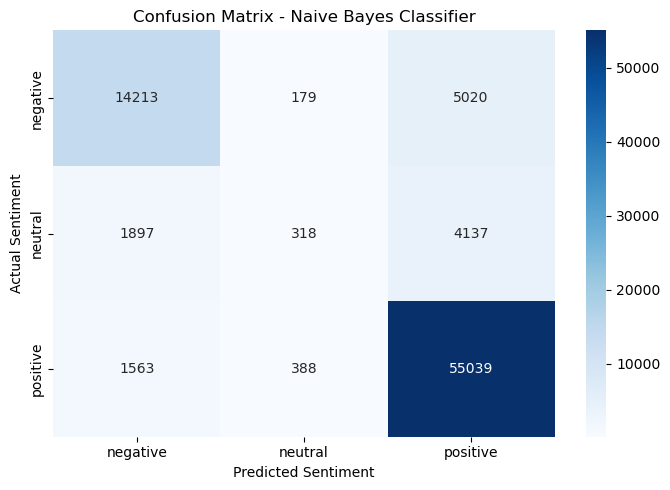

In [ ]:
# Task 6: Print the Confusion Matrix

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix with consistent label ordering
classes = nb_classifier.classes_
cm = confusion_matrix(test_labels, predictions, labels=classes)

print("Confusion Matrix:")
print(cm)
print(f"\nClasses: {list(classes)}")

# Visualize confusion matrix as a heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix - Naive Bayes Classifier")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()
